<a href="https://colab.research.google.com/github/melaniedaniel7/CFPB-NLP-Topic-Analysis/blob/main/CFPB_NLP_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Imported the dataset
from google.colab import files

uploaded = files.upload()

Saving complaints-2026-06-17_10_50.csv to complaints-2026-06-17_10_50 (1).csv


In [4]:
# Checked the dataset uploaded correctly
import pandas as pd

df = pd.read_csv("complaints-2026-06-17_10_50.csv")
df.head()
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company',
       'Company response to consumer', 'Timely response?', 'Complaint ID'],
      dtype='object')

In [5]:
# Checked if any complaint narratives were missing
df.shape
df['Consumer complaint narrative'].isnull().sum()

# Dataset only contains complaint narratives now
complaints = df[['Consumer complaint narrative']].copy()
complaints = complaints.dropna()
complaints.shape

(14965, 1)

In [6]:
# Viewed an example complaint
# Realised that I have to clean the redacted text, represented by "XXX's", when doing text cleaning
complaints.head()
print(complaints['Consumer complaint narrative'].iloc[0])

I was told by XXXX XXXX that XXXX XXXX XXXX  gave them information about the status of my account and whether it was paid off or not and how much I owed. I didnt authorize that information to be given to any one.


In [7]:
# Import libraries and download NLTK resources for text cleaning
import nltk
# These libraries were not mentioned in phase 1 and were an additional add-on for efficient text preprocessing
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag # Import for POS tagging

# Punkt tokenizer for word tokenization
nltk.download('punkt')
# Stopwords list in multiple languages
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError
nltk.download('wordnet') # Added to resolve LookupError for WordNetLemmatizer
nltk.download('averaged_perceptron_tagger') # Added for POS tagging
nltk.download('averaged_perceptron_tagger_eng') # Added to resolve LookupError for averaged_perceptron_tagger_eng

# Create a set of English stopwords for efficient lookup
stop_words = set(stopwords.words('english'))

# Lemmatizer converts words to their base/root form
lemmatizer = WordNetLemmatizer()

# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN # Default to noun if not found

# Function to clean the text by converting text to lowercase, removing digits, removing punctuation, and removing redacted text represented by x's
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'\d+', '', text)
        # Remove patterns like 'xxxx' and 'xxxxyear'
        text = re.sub(r'x{2,}', '', text) # This will remove 'xxxx' and 'xxxxyear' will become 'year'
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\s+', ' ', text)
        return text
    else:
        return text

# Function to tokenize the text into individual words
def tokenize_text(text):
    if isinstance(text, str):
        tokens = word_tokenize(text)
        # The previous filter for set(word.lower()) == {'x'} is now less critical
        # as most 'x' sequences are handled by clean_text, but can keep it as a safeguard.
        tokens = [
            word for word in tokens
            if word and not (len(word) == 1 and word.lower() == 'x') # Exclude single 'x' if it appears
        ]
        return tokens
    else:
        return []

# Function to remove stopwords from the tokenized text
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# Function to apply lemmatization to the tokens with POS tagging
def lemmatize_tokens(tokens):
    if isinstance(tokens, list):
        lemmatized_words = []
        for word, tag in pos_tag(tokens):
            wntag = get_wordnet_pos(tag)
            lemmatized_words.append(lemmatizer.lemmatize(word, wntag))
        return lemmatized_words
    else:
        return tokens

# Test text cleaning techniques on a single consumer complaint before applying text cleaning to the entire dataset
# Used the same complaint example as earlier
sample = df['Consumer complaint narrative'].iloc[0]
print("Original:")
print(sample)
# Clean example complaint
cleaned = clean_text(sample)
print("\nCleaned:")
print(cleaned)
# Tokenize example complaint
tokens = tokenize_text(cleaned)
print("\nTokens:")
print(tokens)
# Remove stopwords from example complaint
filtered = remove_stopwords(tokens)
print("\nNO Stpwords:")
print(filtered)
# Lemmatize example complaint
final = lemmatize_tokens(filtered)
print("\nLemmatized:")
print(final)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Original:
I was told by XXXX XXXX that XXXX XXXX XXXX  gave them information about the status of my account and whether it was paid off or not and how much I owed. I didnt authorize that information to be given to any one.

Cleaned:
i was told by that gave them information about the status of my account and whether it was paid off or not and how much i owed i didnt authorize that information to be given to any one

Tokens:
['i', 'was', 'told', 'by', 'that', 'gave', 'them', 'information', 'about', 'the', 'status', 'of', 'my', 'account', 'and', 'whether', 'it', 'was', 'paid', 'off', 'or', 'not', 'and', 'how', 'much', 'i', 'owed', 'i', 'didnt', 'authorize', 'that', 'information', 'to', 'be', 'given', 'to', 'any', 'one']

NO Stpwords:
['told', 'gave', 'information', 'status', 'account', 'whether', 'paid', 'much', 'owed', 'didnt', 'authorize', 'information', 'given', 'one']

Lemmatized:
['told', 'give', 'information', 'status', 'account', 'whether', 'pay', 'much', 'owe', 'didnt', 'authorize

In [8]:
# Apply the functions to the DataFrame
# Clean the text
df['Cleaned_Complaint'] = df['Consumer complaint narrative'].apply(clean_text)
# Tokenize the cleaned text
df['Tokenized_Complaint'] = df['Cleaned_Complaint'].apply(tokenize_text)
# Remove stopwords from the tokenized text
df['No_Stopwords_Complaint'] = df['Tokenized_Complaint'].apply(remove_stopwords)
# Apply lemmatization to the tokenized words
df['Lemmatized_Complaint'] = df['No_Stopwords_Complaint'].apply(lemmatize_tokens)

# Display the original and lemmatized complaint narratives
display(df[['Consumer complaint narrative', 'Lemmatized_Complaint']].head())

,Consumer complaint narrative,Lemmatized_Complaint
0,I was told by XXXX XXXX that XXXX XXXX XXXX g...,"[told, give, information, status, account, whe..."
1,I have been receiving text messages with a hyp...,"[receive, text, message, hyper, link, payment,..."
2,"To Whom It May Concern, I am submitting this c...","[may, concern, submit, complaint, regard, unau..."
3,I am filing a complaint regarding my mortgage ...,"[file, complaint, regard, mortgage, servicer, ..."
4,XXXX XXXX XXXX XXXX XXXX XXXX XXXX NC XXXX XX/...,"[nc, year, professional, finance, co, co, requ..."


In [9]:
# From testing the BoW approach and the TF-IDF approach with this code, I realised that I needed to filter out numbers in the text cleaning process. I went back and did this beore running the test again and applying the different approaches to the entire dataset.

# Vectorise texts using the BoW approach using the scikit-learn library (Sklearn)
# Pandas was already imported so it does not need to be imported again

from sklearn.feature_extraction.text import CountVectorizer

# To test and compare the BoW approach with the TF-IDF approach, I used the first 5 consumer complaint narratives for complaints related to credit cards
# Using the Lemmatized_Complaint column and joining the tokens into a string
credit_complaint_0 = " ".join(df['Lemmatized_Complaint'].iloc[0])
credit_complaint_1 = " ".join(df['Lemmatized_Complaint'].iloc[2])
credit_complaint_2 = " ".join(df['Lemmatized_Complaint'].iloc[5])
credit_complaint_3 = " ".join(df['Lemmatized_Complaint'].iloc[12])
credit_complaint_4 = " ".join(df['Lemmatized_Complaint'].iloc[16])

vect = CountVectorizer()
data = vect.fit_transform([credit_complaint_0,credit_complaint_1, credit_complaint_2, credit_complaint_3, credit_complaint_4])

# Corrected: Use get_feature_names_out() instead of get_feature_names()
data=pd.DataFrame(data.toarray(),columns=vect.get_feature_names_out())
print(data)

   accept  access  accessible  accord  account  accurate  acknowledge  \
0       0       0           0       0        1         0            0   
1       0       1           1       0        8         1            2   
2       0       0           0       0        0         0            0   
3       2       2           0       2        6         0            1   
4       0       0           0       0        2         0            0   

   acknowledgment  act  action  ...  within  without  would  write  wrong  \
0               0    0       0  ...       0        0      0      0      0   
1               0    0       0  ...       0        2      2      3      0   
2               0    0       0  ...       0        0      0      1      0   
3               2    2       1  ...       3        2      1      6      2   
4               0    0       0  ...       0        0      1      0      0   

   wrongful  year  yet  york  zero  
0         0     0    0     0     0  
1         0     0    0  

In [10]:
# Tried a different approach to see the feature names for BoW to see if I could clean the text any further, but I did not identify any other ways to clean the text or filter out more words.
from sklearn.feature_extraction.text import CountVectorizer

credit_complaint_0 = " ".join(df['Lemmatized_Complaint'].iloc[0])
credit_complaint_1 = " ".join(df['Lemmatized_Complaint'].iloc[2])
credit_complaint_2 = " ".join(df['Lemmatized_Complaint'].iloc[5])
credit_complaint_3 = " ".join(df['Lemmatized_Complaint'].iloc[12])
credit_complaint_4 = " ".join(df['Lemmatized_Complaint'].iloc[16])

vect = CountVectorizer()
data = vect.fit_transform([credit_complaint_0,credit_complaint_1, credit_complaint_2, credit_complaint_3, credit_complaint_4])

print("BoW Matrix: \n", data.toarray())
print("Feature Names: ", vect.get_feature_names_out())


BoW Matrix: 
 [[0 0 0 ... 0 0 0]
 [0 1 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [2 2 0 ... 1 1 2]
 [0 0 0 ... 0 0 0]]
Feature Names:  ['accept' 'access' 'accessible' 'accord' 'account' 'accurate'
 'acknowledge' 'acknowledgment' 'act' 'action' 'activity' 'additional'
 'addon' 'admitted' 'advice' 'agency' 'agree' 'agreement' 'airline'
 'allegation' 'also' 'america' 'annual' 'another' 'arrangement' 'ask'
 'associate' 'attach' 'attached' 'attempt' 'attempted' 'authority'
 'authorization' 'authorize' 'autoacknowledgment' 'autoconvert' 'automate'
 'automatically' 'available' 'aware' 'back' 'balance' 'bank' 'barrier'
 'bear' 'become' 'begin' 'behalf' 'belongs' 'best' 'bill' 'billing' 'bofa'
 'bureau' 'business' 'call' 'cancel' 'cancellation' 'card' 'cardholder'
 'case' 'certify' 'cfpb' 'charge' 'check' 'claim' 'close' 'closure' 'code'
 'collection' 'come' 'commission' 'communication' 'company' 'complaint'
 'complete' 'compliance' 'comptroller' 'concern' 'conclusion' 'conclusive'
 'conduct' 'confirm' 

In [11]:
# Vectorise texts using the TF-IDF approach using the scikit-learn library (Sklearn)
# Pandas was already imported so it does not need to be imported again

from sklearn.feature_extraction.text import TfidfVectorizer

# To test and compare the BoW approach with the TF-IDF approach, I used the first 5 consumer complaint narratives for complaints related to credit cards
# Using the Lemmatized_Complaint column and joining the tokens into a string
credit_complaint_0 = " ".join(df['Lemmatized_Complaint'].iloc[0])
credit_complaint_1 = " ".join(df['Lemmatized_Complaint'].iloc[2])
credit_complaint_2 = " ".join(df['Lemmatized_Complaint'].iloc[5])
credit_complaint_3 = " ".join(df['Lemmatized_Complaint'].iloc[12])
credit_complaint_4 = " ".join(df['Lemmatized_Complaint'].iloc[16])

vectorizer = TfidfVectorizer(min_df=1)
model = vectorizer.fit_transform([credit_complaint_0,credit_complaint_1, credit_complaint_2, credit_complaint_3, credit_complaint_4])
data=pd.DataFrame(model.toarray(),columns=vectorizer.get_feature_names_out())
print(data)

     accept    access  accessible    accord   account  accurate  acknowledge  \
0  0.000000  0.000000    0.000000  0.000000  0.156488  0.000000     0.000000   
1  0.000000  0.042258    0.052378  0.000000  0.236071  0.052378     0.084517   
2  0.000000  0.000000    0.000000  0.000000  0.000000  0.000000     0.000000   
3  0.050734  0.040932    0.000000  0.050734  0.085747  0.000000     0.020466   
4  0.000000  0.000000    0.000000  0.000000  0.109431  0.000000     0.000000   

   acknowledgment       act    action  ...  within   without     would  \
0        0.000000  0.000000  0.000000  ...  0.0000  0.000000  0.000000   
1        0.000000  0.000000  0.000000  ...  0.0000  0.084517  0.070157   
2        0.000000  0.000000  0.000000  ...  0.0000  0.000000  0.000000   
3        0.050734  0.050734  0.025367  ...  0.0761  0.040932  0.016988   
4        0.000000  0.000000  0.000000  ...  0.0000  0.000000  0.065042   

      write     wrong  wrongful      year       yet      york      zero  


In [12]:
# From the BoW and TF-IDF tests, I was not able to say one approach was better than the other, so I applied both approaches to the entire dataset to see which would be more efficient.

# BoW approach
from sklearn.feature_extraction.text import CountVectorizer

# Join the lemmatized tokens into a single string for each complaint
df['Lemmatized_Complaint_String'] = df['Lemmatized_Complaint'].apply(lambda x: ' '.join(x))

vect = CountVectorizer()
BoW_matrix = vect.fit_transform(df['Lemmatized_Complaint_String'])

# Create a DataFrame for the BoW matrix, using the feature names
BoW_df = pd.DataFrame(BoW_matrix.toarray(), columns=vect.get_feature_names_out())

print("Shape of BoW matrix:", BoW_matrix.shape)
display(BoW_df.head())


Shape of BoW matrix: (14965, 20974)


,aa,aaa,aacd,aadvantage,aadvantagebarclay,aadvantagecard,aafes,aafesmilitary,aaffees,aargon,...,zoca,zombie,zone,zoom,zs,zuntafi,zuntafias,zuntafil,zwicker,zwickers
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# TF-IDF approach
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens into a single string for each complaint
df['Lemmatized_Complaint_String'] = df['Lemmatized_Complaint'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(min_df=1)
TFIDF_matrix = vectorizer.fit_transform(df['Lemmatized_Complaint_String'])

TFIDF_df = pd.DataFrame(TFIDF_matrix.toarray(),columns=vectorizer.get_feature_names_out())

print("Shape of TF-IDF matrix:", TFIDF_matrix.shape)
display(TFIDF_df.head())

Shape of TF-IDF matrix: (14965, 20974)


,aa,aaa,aacd,aadvantage,aadvantagebarclay,aadvantagecard,aafes,aafesmilitary,aaffees,aargon,...,zoca,zombie,zone,zoom,zs,zuntafi,zuntafias,zuntafil,zwicker,zwickers
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Using LSA and the TF-IDF approach to find the most prevalent topics (sample test)

from sklearn.decomposition import TruncatedSVD

# First, a test will be run using the same first 5 credit card consumer complaints, like before.
credit_complaint_0 = " ".join(df['Lemmatized_Complaint'].iloc[0])
credit_complaint_1 = " ".join(df['Lemmatized_Complaint'].iloc[2])
credit_complaint_2 = " ".join(df['Lemmatized_Complaint'].iloc[5])
credit_complaint_3 = " ".join(df['Lemmatized_Complaint'].iloc[12])
credit_complaint_4 = " ".join(df['Lemmatized_Complaint'].iloc[16])

# Increased max_features to be at least n_components (8), here set to 10 for flexibility
vectorizer = TfidfVectorizer(use_idf=True, max_features=10, smooth_idf=True)
model = vectorizer.fit_transform([credit_complaint_0,credit_complaint_1, credit_complaint_2, credit_complaint_3, credit_complaint_4])

# Here we are going to test this method with 8 topics
LSA_model = TruncatedSVD(n_components=8, algorithm='randomized', n_iter=10)
lsa = LSA_model.fit_transform(model)

# This gives a percentage of how much the complaints compare to the main topics from the first complaint
# I used the textbook to guide me here, but I didn't achieve what I wanted to with this code. However, it was still insightful and helped me focus more on what I wanted to achieve when applying LSA to the entire corpus.
l=lsa[0]
print("Complaint 0 :")
for i,topic in enumerate(l):
  print("Topic ",i," : ",topic*100)

Complaint 0 :
Topic  0  :  54.36543499509446
Topic  1  :  67.20484684316706
Topic  2  :  -32.82939833973095
Topic  3  :  -38.070157195483475
Topic  4  :  0.8954185295566606


In [15]:
# Using LSA and the TF-IDF approach to find the most prevalent topics (corpus test)

# Import libraries and dependencies
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd # Import pandas as it's used for DataFrame
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer here

svd_model = TruncatedSVD(n_components=12) # Test on 12 topics
lsa = svd_model.fit_transform(TFIDF_matrix)

topic_encoded_df = pd.DataFrame(lsa, columns = ["topic_" + str(i) for i in range(lsa.shape[1])])
topic_encoded_df["Consumer Complaints"] = df['Lemmatized_Complaint_String']
topic_encoded_df.head()

def extract_main_topics(x):
    """
    Return the main topic for each document. The main topic is that have the maximum value for each line
    """
    topics = np.abs(x)
    main_topic = topics.sort_values(ascending=False).index[0]
    return main_topic

# Initialize column main_topics with 0
topic_encoded_df.loc[:, 'main_topic'] = '' # Initialize as string to avoid FutureWarning

for i, row in topic_encoded_df.iloc[:,:-2].iterrows():
    topic_encoded_df.loc[i, 'main_topic'] = extract_main_topics(row)

topic_encoded_df.head()

topic_encoded_df['main_topic'].value_counts()

# Re-initialize and fit the TfidfVectorizer on the full dataset to get all feature names
vectorizer = TfidfVectorizer(min_df=1)
vectorizer.fit(df['Lemmatized_Complaint_String'])

# Create DataFrame containing the description of each topic in terms of the words in the vocabulary
topics_description = pd.DataFrame(svd_model.components_, columns = vectorizer.get_feature_names_out(),
                                  index = ['topic_' + str(i) for i in range(svd_model.components_.shape[0])])

# Compute absolute values of coefficients
topics_description = topics_description.apply(np.abs, axis = 1)

# Each word is map with a score of relevance for each topic
topics_description.head()

# Loop over each topic and print the 5 most important words
for i,row in topics_description.iterrows():
    print('TOPIC :', i)
    print(row.sort_values(ascending=False)[0:5].index.tolist())
    print()
    print('-------------------------')
    print()

topic_encoded_df.head()



TOPIC : topic_0
['debt', 'account', 'report', 'credit', 'collection']

-------------------------

TOPIC : topic_1
['debt', 'report', 'falsely', 'credit', 'verification']

-------------------------

TOPIC : topic_2
['usc', 'accurate', 'report', 'payment', 'entry']

-------------------------

TOPIC : topic_3
['falsely', 'accurate', 'usc', 'credit', 'entry']

-------------------------

TOPIC : topic_4
['falsely', 'debt', 'account', 'documentation', 'entitle']

-------------------------

TOPIC : topic_5
['payment', 'loan', 'card', 'call', 'mortgage']

-------------------------

TOPIC : topic_6
['account', 'card', 'loan', 'dispute', 'verification']

-------------------------

TOPIC : topic_7
['account', 'merchant', 'charge', 'payment', 'transaction']

-------------------------

TOPIC : topic_8
['charge', 'loan', 'balance', 'identity', 'interest']

-------------------------

TOPIC : topic_9
['violate', 'cfr', 'yet', 'need', 'place']

-------------------------

TOPIC : topic_10
['company', 't

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,Consumer Complaints,main_topic
0,0.123935,-0.042742,-0.075295,-0.054521,0.032282,-0.054122,0.001565,0.100796,-0.033385,-0.013535,0.055526,0.004923,told give information status account whether p...,topic_0
1,0.113612,-0.048527,-0.106698,-0.083685,0.060115,-0.009716,-0.053567,0.089096,-0.065354,-0.032700,0.065155,0.035160,receive text message hyper link payment explan...,topic_0
2,0.251229,-0.112511,-0.174579,-0.058497,-0.049487,-0.029350,0.077209,-0.030583,-0.008381,-0.048861,-0.050263,0.025015,may concern submit complaint regard unauthoriz...,topic_0
3,0.156154,-0.097268,-0.181831,-0.089746,0.043335,0.188575,-0.107420,-0.040480,-0.109759,-0.027957,-0.025449,0.015356,file complaint regard mortgage servicer shellp...,topic_5
4,0.609132,0.217209,0.000620,0.045393,-0.109850,-0.067030,-0.072986,0.009448,0.115304,-0.078348,-0.055681,0.085017,nc year professional finance co co request deb...,topic_0


In [17]:
# Using LDA and the BoW approach to find the most prevalent topics (sample test using the textbook again)
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation

# First, a test will be run using the same first 5 credit card consumer complaints, like before.
credit_complaint_0 = " ".join(df['Lemmatized_Complaint'].iloc[0])
credit_complaint_1 = " ".join(df['Lemmatized_Complaint'].iloc[2])
credit_complaint_2 = " ".join(df['Lemmatized_Complaint'].iloc[5])
credit_complaint_3 = " ".join(df['Lemmatized_Complaint'].iloc[12])
credit_complaint_4 = " ".join(df['Lemmatized_Complaint'].iloc[16])

vectorizer = TfidfVectorizer(use_idf=True,
 max_features=10,
 smooth_idf=True)
model = vectorizer.fit_transform([credit_complaint_0,credit_complaint_1, credit_complaint_2, credit_complaint_3, credit_complaint_4])

lda_model=LatentDirichletAllocation(n_components=8,learning_method='online',random_state=42,max_iter=10)
lda_top=lda_model.fit_transform(model)

print("Complaint 0: ")
for i,topic in enumerate(lda_top[0]):
 print("Topic ",i,": ",topic*100,"%")

Complaint 0: 
Topic  0 :  6.251825284791089 %
Topic  1 :  6.251300794256855 %
Topic  2 :  6.258907284447386 %
Topic  3 :  6.251058849571136 %
Topic  4 :  56.23448944598526 %
Topic  5 :  6.250795037095935 %
Topic  6 :  6.250684043648443 %
Topic  7 :  6.2509392602039044 %


In [ ]:
# For these sample tests, although the words that make up each topic aren't defined, there is already a significant difference in the output.
# LSA is constrained by the actual dimensions of the data, which is why there are only 5 topics despite specifying "n_components=8".
# LDA, on the other hand, is more flexible in generating the specified number of topic distributions.

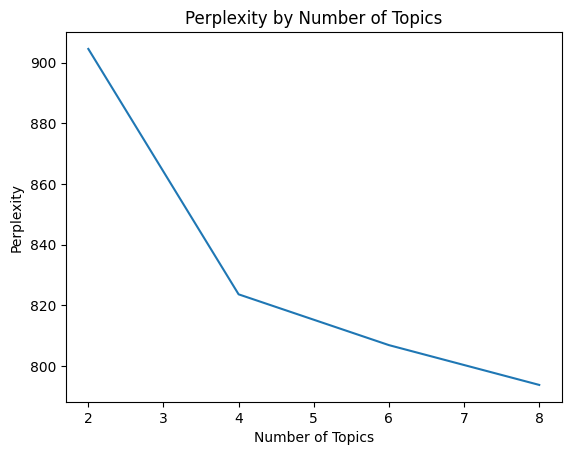

Topic 1:
debt, account, report, credit, collection


Topic 2:
call, credit, account, card, pay


Topic 3:
dispute, charge, credit, account, card


Topic 4:
document, mortgage, property, letter, notice


Topic 5:
payment, account, loan, request, balance




In [30]:
# Using LDA and the BoW approach to find the most prevalent topics (corpus test)

# Import libraries and dependencies
import pandas as pd
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt # Added import for plotting

# We will use BoW_matrix as the input corpus for LDA directly.
X = BoW_matrix

# Get the vocabulary (feature names) from the CountVectorizer that created BoW_matrix.
vocabulario = vect.get_feature_names_out()

# Function to compute coherence and perplexity values for different numbers of topics
def compute_coherence_values(corpus, start, limit, step): # Removed 'vectorizer' from arguments
    coherence_values = []
    perplexity_values = []

    # Loop over the range of topics from start to limit, with the specified step
    for num_topics in range(start, limit, step):
        # Create an LDA model with the current number of topics
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(corpus)

        # Compute perplexity for the current model
        perplexity = lda_model.perplexity(corpus)
        perplexity_values.append(perplexity)

        # Compute model score as an approximation for coherence
        coherence_values.append(lda_model.score(corpus))

    # Return both coherence and perplexity values
    return coherence_values, perplexity_values

# Define the range for the number of topics
start, limit, step = 2, 10, 2

# Compute coherence and perplexity values for different numbers of topics
coherence_values, perplexity_values = compute_coherence_values(X, start, limit, step) # Called without 'vectorizer' argument

# Plotting the perplexity values
plt.plot(range(start, limit, step), perplexity_values)
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("Perplexity by Number of Topics")
plt.grid(False)
plt.show()

# Define the number of topics
# Change this value to set the desired number of topics
# Selecting the model based on the coherence value
best_num_topics = np.argmin(perplexity_values) + start

# LDA Model
lda_model = LatentDirichletAllocation(n_components=best_num_topics, random_state=42)
lda_model.fit(X)

# Function to display topics with keywords
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(", ".join(top_words))
        print("\n")

# Number of words per topic
no_top_words = 5

# Display the keywords of the topics
feature_names = vocabulario # Corrected: Use vocabulario from the CountVectorizer for the full dataset
display_topics(lda_model, feature_names, no_top_words)

In [29]:
# Get topic distributions for the first 5 complaints
lda_topic_distributions = lda_model.transform(X[:5])

# Create a DataFrame for topic distributions
lda_topic_df = pd.DataFrame(lda_topic_distributions,
                              columns=[f'Topic_{i+1}' for i in range(best_num_topics)])

# Add the original consumer complaint narratives
lda_topic_df["Consumer Complaints"] = df['Lemmatized_Complaint_String'].head(5).reset_index(drop=True)

# Determine the main topic for each complaint
# Use 'idxmax' to get the column name (topic) with the highest probability for each row
lda_topic_df['Main_Topic'] = lda_topic_df[[f'Topic_{i+1}' for i in range(best_num_topics)]].idxmax(axis=1)

# Display the resulting DataFrame
display(lda_topic_df)

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Consumer Complaints,Main_Topic
0,0.184428,0.670254,0.013864,0.013489,0.117965,told give information status account whether p...,Topic_2
1,0.009371,0.962517,0.009400,0.009195,0.009518,receive text message hyper link payment explan...,Topic_2
2,0.169125,0.110368,0.694956,0.000979,0.024572,may concern submit complaint regard unauthoriz...,Topic_3
3,0.000845,0.119890,0.000847,0.000841,0.877577,file complaint regard mortgage servicer shellp...,Topic_5
4,0.992466,0.001876,0.001891,0.001884,0.001883,nc year professional finance co co request deb...,Topic_1
